# Chain-of-Thought Prompting versus Fine-Tuning for Table Reasoning in Small Language Models

**Adisesh Venkatesh, Amar Thota, Nikhil Karthikeyan, Sanjay Manivasagam, Anant Madhok**

*University of California, Davis — ECS 111: Machine Learning*

> Final report. Every table and figure below is computed live from `results/*.json`;
> the prose numbers are copied from `report/PAPER.md`, which is itself filled from the
> same result files. Run all cells to regenerate every number and chart.

## Abstract

When only a small, free-tier language model is available, is it better to spend effort on chain-of-thought (CoT) prompting or on supervised fine-tuning to make the model answer questions about tables? We run a controlled comparison on FLAN-T5-base (250M) and FLAN-T5-large (780M) over WikiTableQuestions (WTQ) and a held-out generalization test on TabFact, with two random seeds per condition and every reported number traced to a result file rather than hand-typed. The result is negative and consistent: no method we tried beat a plain zero-shot baseline. The strongest system overall was FLAN-T5-large prompted with no examples, at 0.241 exact match; few-shot CoT *more than halved* exact match (plain CoT: 0.015 base, 0.052 large), and light fine-tuning of the base model landed below its own baseline (0.157 answers-only, 0.121 with reasoning traces, versus 0.171 baseline). On the out-of-distribution TabFact transfer, the fine-tuned models did not transfer at all: they almost never emitted a gradeable true/false token (0.5% mappable outputs), so their 0.1–0.3% accuracy reflects an output-format collapse under distribution shift, not table-fact reasoning, and sits below the 0.551 majority-class floor for that reason. We trace the CoT degradation to a format effect — small models reason in prose while strict exact match rewards the bare cell — and we confirm the headline prompting-vs-fine-tuning gap is statistically real (McNemar, p < 10⁻¹³). We conclude that, at this scale and compute budget, the highest-leverage choice is the largest model one can prompt plainly, with careful output formatting, rather than CoT or a quick fine-tune.

## 1. Introduction

Tables are a default container for real-world data: medical records, government statistics, financial reports, and sports results all live in rows and columns. A language model that cannot read a table reliably is of limited use regardless of its fluency on free text. Yet table question answering is deceptively hard: it is a multi-step pipeline — understand the question, locate the relevant cells, choose the right operation (filter, count, compare, sort), and return the answer in the expected format — in which a slip at any step yields a confident wrong answer.

Two standard remedies exist. **Chain-of-thought (CoT) prompting** guides the model through intermediate reasoning at inference time, changing only the prompt and requiring no training. **Supervised fine-tuning** instead updates the model's weights on question/answer pairs. The published evidence for both is dominated by very large, expensive models. Wei et al. [5] reported that CoT is an emergent benefit of scale and that small models gain far less from it; most fine-tuning evidence likewise assumes compute that a student or hobbyist on a free Colab GPU does not have.

This report studies the under-explored regime directly: **both methods applied to small models that anyone can run for free**, under a strict budget (a single free Colab T4, under two hours per condition). We ask a sharp, practical question — *when you cannot afford a 100B-parameter model, which lever helps table reasoning more, prompting or fine-tuning, and where does each one break?* We contribute:

1. A controlled comparison of zero-shot, two CoT prompt styles, and two fine-tuning recipes on the *same* small models (FLAN-T5-base and -large), with two seeds and reproducible seeded data slices.
2. A cross-dataset generalization test (train on WTQ, evaluate on TabFact with zero TabFact training) that isolates transfer from memorization.
3. An honest decomposition of the TabFact transfer result that separates *reasoning* failure from *output-format* failure — the distinction that makes the near-zero numbers interpretable.
4. A failure analysis (error-type breakdown, chain-quality rating with inter-rater agreement, and a paired significance test) and a full provenance discipline in which every reported number is regenerated from a result file by a script that fails loudly on any unmapped figure.

Our findings are negative, and we report them as such: no condition beat the plain baseline. We argue this is itself a useful, reproducible result for the small-model regime, and we explain the mechanisms behind it.

## 2. Related Work

**Chain-of-thought prompting.** Wei et al. [5] introduced CoT prompting and showed it elicits reasoning primarily in models above roughly 100B parameters, explicitly noting that smaller models benefit far less and can even be hurt. Subsequent work improved CoT for large models — self-consistency [4] aggregates multiple sampled chains, and tree-of-thoughts [7] searches over reasoning branches — but these add inference cost and target large models, and none focus on tables. Our work tests the small-model boundary Wei et al. flagged, on a structured-input task, under a fixed compute cap.

**Table question answering and verification.** WikiTableQuestions [3] established compositional QA over semi-structured tables (filtering, aggregation, comparison, multi-hop). TabFact [1] framed table understanding as binary fact verification (true/false over a statement and a table). TAPAS [2] trained a table-specialized encoder via weak supervision but without explicit step-by-step reasoning. UnifiedSKG [6] unified many structured-knowledge tasks under a text-to-text interface and is the closest prior framing to ours, but it does not pit prompting against fine-tuning as a controlled experiment, nor does it operate under strict free-tier compute limits.

**Position of this work.** The individual ingredients — CoT, table QA, seq2seq fine-tuning — are established. The specific combination is not: a controlled prompting-vs-fine-tuning comparison *at 250M–780M scale*, on WTQ and TabFact, *under a free-Colab budget*, with a cross-dataset transfer test and an error-type breakdown. The gap we fill is empirical evidence for practitioners who cannot scale.

## 3. Methodology

### 3.1 Models

We use the FLAN-T5 family: FLAN-T5-base (250M parameters) and FLAN-T5-large (780M). The base model is both prompted and fine-tuned; the large model is prompt-only, because fine-tuning it exhausts the 16 GB of a free Colab T4. FLAN-T5-small (80M) is used only for a fast end-to-end smoke check, never for reported numbers. All generation is greedy (`do_sample=False`, `num_beams=1`), making decoding deterministic.

### 3.2 Datasets

Both datasets load from the HuggingFace Hub with no account or API key. Because `datasets >= 4.0` removed script-based datasets, the canonical `wikitablequestions` and `tab_fact` ids no longer load; we use content-identical parquet mirrors. **WTQ** comes from `lighteval/wikitablequestions` as a single 18,486-example pool, from which we carve a *fixed, seeded, disjoint* train/eval partition that never overlaps. **TabFact** comes from `target-benchmark/tabfact-queries` joined to `tabfact-corpus` on `table_id`. Every table is serialized to text — column headers first, then each row, cells delimited by a bar — to fit the small models' token limits. WTQ is the primary train-and-test task; TabFact is used *only* for evaluation, never for training, so a fine-tuned model's TabFact performance measures transfer rather than memorization.

### 3.3 Conditions

We evaluate six conditions, ordered so earlier ones stand alone:

| # | Condition | Model(s) | Training | Description |
|---|-----------|----------|----------|-------------|
| C0 | Baseline | base + large | none | Question + serialized table, no examples. The floor. |
| CA-plain | CoT, plain | base + large | none | Six hand-written exemplars with free-paragraph reasoning prepended. |
| CA-struct | CoT, structured | base + large | none | Same six exemplars, reasoning as a fixed step template. |
| CB | Fine-tune, answers-only | base | yes | Target = final answer only (standard fine-tuning). |
| CC | Fine-tune, + reasoning traces | base | yes | Target = a rule-generated reasoning chain ending in the answer. |
| CG | Generalization | CB & CC models, + base floor | none | The fine-tuned (and untrained-base) models evaluated on TabFact, zero TabFact training. |

The two CoT styles let us separate *whether* reasoning demonstrations help from *whether their format* matters. The reasoning traces in CC are produced by rule-based templates that emit a chain only when the derivation is unambiguous and otherwise fall back to the plain answer, so a wrong chain never enters training; coverage was 3,740 of 8,000 training rows (46.8%) for both seeds.

### 3.4 Training

Fine-tuning uses one recipe for both CB and CC to keep the comparison fair: AdamW, learning rate 3×10⁻⁴, batch size 8 with gradient accumulation 4 (effective batch 32), three epochs, on a T4. The only difference between CB and CC is the target text. Each condition runs twice, with seeds 13 and 42, and we report mean ± standard deviation across the two.

### 3.5 Evaluation and Statistics

The official run evaluates on 1,000 examples for the baseline, fine-tuning, and TabFact conditions, and on 500 for the slower CoT conditions; the training pool is 8,000 examples. Metrics: **exact match** (primary WTQ metric; normalized by lowercasing and punctuation removal); **token-level F1** (partial credit where EM is too strict); **classification accuracy** for TabFact (free-form output mapped to true/false by a keyword verbalizer — `true/yes/entail/supported/correct` → true; `false/no/refut/contradict/incorrect` → false — with non-matching outputs counted unmappable and wrong); an **error-type breakdown** (each wrong WTQ answer labeled lookup / aggregation / multi-hop); **chain quality** (100 sampled CoT chains scored 0/1/2 by two independent rubrics, with Cohen's κ); and **compute** (inference seconds per example). For the headline comparison we run **McNemar's exact test** on paired per-example correctness. Provenance is enforced mechanically: `report_fill.py` maps each figure to a result JSON and `finalize_report.py` exits non-zero on any unmapped token, so no number here is hand-typed.

In [1]:
# --- setup: resolve repo root (notebook runs from report/ under nbconvert) ---
import os, sys, json
from pathlib import Path
import statistics as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir())
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src import analysis
from src.report_fill import _tabfact_decomp, _tabfact_floor

# src.analysis sets the headless "Agg" backend on import (it saves figures to disk);
# switch to the inline backend so figures render INSIDE this notebook.
%matplotlib inline

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "axes.axisbelow": True,
                     "grid.alpha": 0.3, "font.size": 10})

RESULTS = analysis.load_results()

def _pick(cond, short, task="wtq"):
    return [r for r in RESULTS if r["condition"] == cond and r["task"] == task
            and r["model"].split("/")[-1] == f"flan-t5-{short}"]

def _ms(vals):
    vals = list(vals)
    return (st.fmean(vals), st.pstdev(vals) if len(vals) > 1 else 0.0) if vals else (None, None)

print(f"Loaded {len(RESULTS)} result files from {ROOT/'results'}")

Loaded 22 result files from /Users/sanjaym/Downloads/ECS111FinalProject/results


## 4. Experiments and Results

### 4.1 Main task: WikiTableQuestions

Table 1 reports exact match and token-F1 for every WTQ condition, as mean ± std over seeds 13 and 42, computed live from the result files.

In [2]:
# Table 1: WTQ exact match + token-F1 (mean +/- std over 2 seeds)
order = [("baseline","base"),("baseline","large"),("cot_plain","base"),("cot_plain","large"),
         ("cot_structured","base"),("cot_structured","large"),
         ("finetune_answers","base"),("finetune_traces","base")]
rows = []
for cond, short in order:
    rs = _pick(cond, short)
    if not rs:
        continue
    em = _ms(r["metrics"]["exact_match"] for r in rs)
    f1 = _ms(r["metrics"]["token_f1"] for r in rs)
    rows.append({"Condition": cond, "Model": f"flan-t5-{short}",
                 "Exact Match": f"{em[0]:.3f} ± {em[1]:.3f}",
                 "Token-F1": f"{f1[0]:.3f} ± {f1[1]:.3f}"})
table1 = pd.DataFrame(rows)
table1

,Condition,Model,Exact Match,Token-F1
0,baseline,flan-t5-base,0.171 ± 0.011,0.204 ± 0.011
1,baseline,flan-t5-large,0.241 ± 0.009,0.279 ± 0.011
2,cot_plain,flan-t5-base,0.015 ± 0.001,0.062 ± 0.001
3,cot_plain,flan-t5-large,0.052 ± 0.008,0.099 ± 0.007
4,cot_structured,flan-t5-base,0.019 ± 0.003,0.059 ± 0.001
5,cot_structured,flan-t5-large,0.147 ± 0.015,0.197 ± 0.011
6,finetune_answers,flan-t5-base,0.157 ± 0.002,0.207 ± 0.006
7,finetune_traces,flan-t5-base,0.121 ± 0.009,0.158 ± 0.012


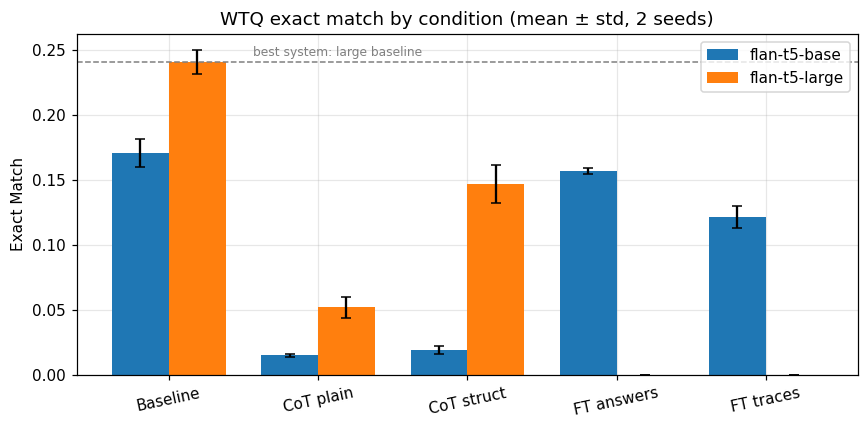

In [3]:
# Figure 1: WTQ exact match by condition and model (error bars = std over seeds)
conds = ["baseline","cot_plain","cot_structured","finetune_answers","finetune_traces"]
labels = ["Baseline","CoT plain","CoT struct","FT answers","FT traces"]
def em_of(cond, short):
    m, s = _ms(r["metrics"]["exact_match"] for r in _pick(cond, short))
    return (0.0 if m is None else m), (0.0 if s is None else s)
base = [em_of(c, "base") for c in conds]
large = [em_of(c, "large") for c in conds]
x = np.arange(len(conds)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [m for m,_ in base], w, yerr=[s for _,s in base], capsize=3, label="flan-t5-base")
ax.bar(x + w/2, [m for m,_ in large], w, yerr=[s for _,s in large], capsize=3, label="flan-t5-large")
ax.axhline(max(m for m,_ in large), ls="--", c="gray", lw=1)
ax.annotate("best system: large baseline", (0.5, max(m for m,_ in large)),
            textcoords="offset points", xytext=(6, 4), fontsize=8, color="gray")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=12)
ax.set_ylabel("Exact Match"); ax.set_title("WTQ exact match by condition (mean ± std, 2 seeds)")
ax.legend(); plt.tight_layout(); plt.show()

Three results stand out. **The plain baseline is the best system at every comparison.** FLAN-T5-large with no examples reaches 0.241 EM, the highest number anywhere in the study; the base baseline (0.171) also beats every base-model method. **CoT degrades exact match severely.** Plain CoT collapses the base model to 0.015 and the large model to 0.052 — a drop of more than 4× and 4.6× from their baselines. Structured-step CoT is less destructive on the large model (0.147) but still well under its 0.241 baseline, and on the base model it is no better than plain CoT (0.019). **Fine-tuning does not beat the baseline either:** answers-only fine-tuning reaches 0.157 (below the 0.171 base baseline), and adding reasoning traces makes it *worse* at 0.121. Figure 2 shows why CoT looks so bad under exact match: token-F1 stays well above EM, so the model produces relevant content but not in the bare-cell form EM rewards.

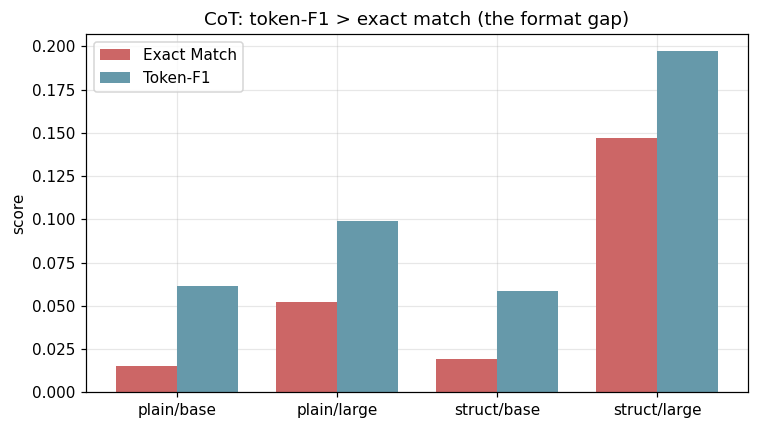

In [4]:
# Figure 2: CoT format effect -- token-F1 exceeds exact match (content survives, form fails)
pairs = [("cot_plain","base"),("cot_plain","large"),("cot_structured","base"),("cot_structured","large")]
plabs = ["plain/base","plain/large","struct/base","struct/large"]
emv = [_ms(r["metrics"]["exact_match"] for r in _pick(c,s))[0] for c,s in pairs]
f1v = [_ms(r["metrics"]["token_f1"] for r in _pick(c,s))[0] for c,s in pairs]
x = np.arange(len(pairs)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, emv, w, label="Exact Match", color="#c66")
ax.bar(x + w/2, f1v, w, label="Token-F1", color="#69a")
ax.set_xticks(x); ax.set_xticklabels(plabs)
ax.set_ylabel("score"); ax.set_title("CoT: token-F1 > exact match (the format gap)")
ax.legend(); plt.tight_layout(); plt.show()

### 4.2 Generalization: TabFact transfer

The TabFact eval uses a prompt that explicitly asks for true or false, and scoring maps free-form output to a label via the verbalizer above, so the test is fair. The gold split on the 1,000-example slice is 551 false / 449 true, giving a majority-class floor of 0.551. We report four quantities per model, because raw accuracy alone is misleading here (Table 2, Figure 3).

Majority-class floor = 0.551


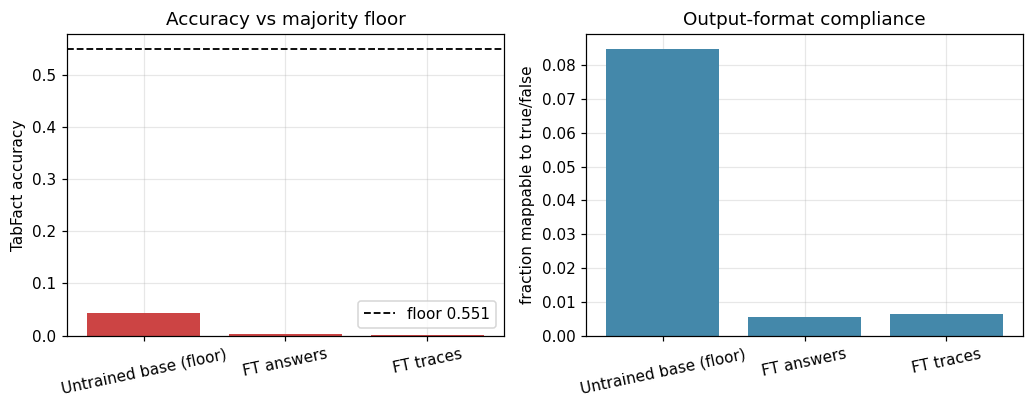

,Model,Accuracy,Mappable,Unmappable,Acc | mappable
0,Untrained base (floor),0.043 ± 0.000,170 / 2000,0.915,0.506 (n=170)
1,FT answers,0.003 ± 0.001,11 / 2000,0.995,0.455 (n=11)
2,FT traces,0.002 ± 0.001,13 / 2000,0.994,0.308 (n=13)


In [5]:
# Table 2 + Figure 3: TabFact transfer decomposition (pooled over 2 seeds, n = 2000)
floor = _tabfact_floor(RESULTS)
gen = [("generalization_baseline","Untrained base (floor)"),
       ("generalization_finetune_answers","FT answers"),
       ("generalization_finetune_traces","FT traces")]
rows = []
for cond, label in gen:
    d = _tabfact_decomp(RESULTS, cond)
    acc = _ms(r["metrics"]["classification_accuracy"] for r in RESULTS
              if r["condition"] == cond and r["task"] == "tabfact")
    rows.append({"Model": label, "Accuracy": f"{acc[0]:.3f} ± {acc[1]:.3f}",
                 "Mappable": f"{d['coverage_n']} / {d['n']}",
                 "Unmappable": f"{d['unmappable_rate']:.3f}",
                 "Acc | mappable": (f"{d['acc_given_mappable']:.3f} (n={d['coverage_n']})"
                                    if d["acc_given_mappable"] is not None else "n/a")})
table2 = pd.DataFrame(rows)
print(f"Majority-class floor = {floor:.3f}")

mods = [lbl for _, lbl in gen]
accs = [_ms(r["metrics"]["classification_accuracy"] for r in RESULTS
            if r["condition"] == c and r["task"] == "tabfact")[0] for c, _ in gen]
covs = [(lambda d: d["coverage_n"] / d["n"])(_tabfact_decomp(RESULTS, c)) for c, _ in gen]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.8))
a1.bar(mods, accs, color="#c44"); a1.axhline(floor, ls="--", c="k", lw=1.2, label=f"floor {floor:.3f}")
a1.set_ylabel("TabFact accuracy"); a1.set_title("Accuracy vs majority floor")
a1.tick_params(axis="x", rotation=12); a1.legend()
a2.bar(mods, covs, color="#48a"); a2.set_ylabel("fraction mappable to true/false")
a2.set_title("Output-format compliance"); a2.tick_params(axis="x", rotation=12)
plt.tight_layout(); plt.show()
table2

The accuracy numbers (0.1–4.3%) are far below both the 60% target set in our proposal and the 0.551 majority floor. The decomposition explains why: the models almost never emit a gradeable true/false token. The untrained base produces a mappable answer only 8.5% of the time; the WTQ-fine-tuned models produce one 0.5% of the time, having locked into short WTQ-style outputs (the answers model emitted the literal token `0` 153 times in a single seed). Critically, *when* the untrained base does answer in-format, it is correct 0.506 of the time — exactly chance. The fine-tuned conditional rates rest on 11 and 13 examples and are not interpretable. This is an output-format collapse under distribution shift, not anti-correlation with truth: the models did not learn to verify facts, and fine-tuning on WTQ made the format mismatch strictly worse.

### 4.3 Error analysis

Every wrong WTQ answer is labeled by reasoning type. Table 3 and Figure 4 give the share of each error type among wrong answers, pooled over both seeds.

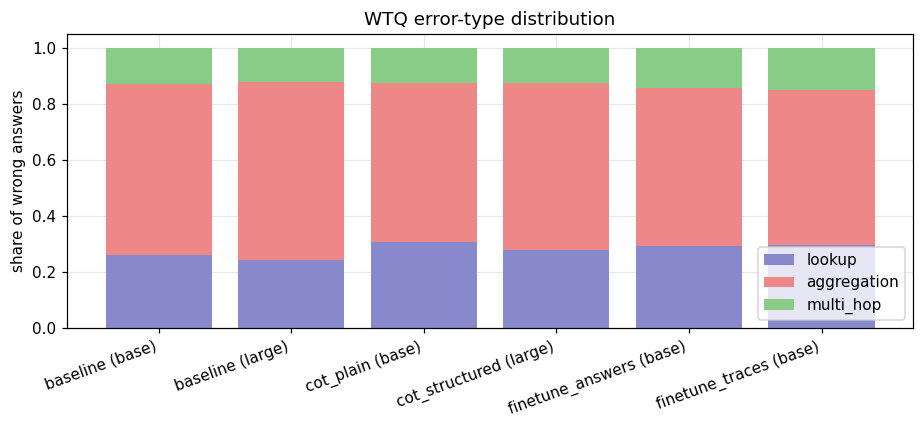

,Condition,Lookup,Aggregation,Multi-hop
0,baseline (base),26%,61%,13%
1,baseline (large),24%,64%,12%
2,cot_plain (base),31%,57%,13%
3,cot_structured (large),28%,60%,13%
4,finetune_answers (base),29%,57%,14%
5,finetune_traces (base),30%,55%,15%


In [6]:
# Table 3 + Figure 4: WTQ error-type share among wrong answers (pooled over seeds)
from collections import defaultdict
agg = defaultdict(lambda: defaultdict(int))
for r in RESULTS:
    if r["task"] != "wtq" or not r["error_distribution"]:
        continue
    key = (r["condition"], r["model"].split("/")[-1])
    for k, v in r["error_distribution"].items():
        agg[key][k] += v
econds = [("baseline","flan-t5-base"),("baseline","flan-t5-large"),
          ("cot_plain","flan-t5-base"),("cot_structured","flan-t5-large"),
          ("finetune_answers","flan-t5-base"),("finetune_traces","flan-t5-base")]
share, rows = {}, []
for key in econds:
    e = agg[key]; wrong = sum(e.values()) - e.get("correct", 0)
    sh = {t: e.get(t, 0) / wrong for t in ("lookup","aggregation","multi_hop")}
    share[key] = sh
    rows.append({"Condition": f"{key[0]} ({key[1].split('-')[-1]})",
                 "Lookup": f"{sh['lookup']*100:.0f}%",
                 "Aggregation": f"{sh['aggregation']*100:.0f}%",
                 "Multi-hop": f"{sh['multi_hop']*100:.0f}%"})
table3 = pd.DataFrame(rows)

x = np.arange(len(econds)); bottom = np.zeros(len(econds))
fig, ax = plt.subplots(figsize=(8.5, 4))
for t, c in [("lookup","#88c"),("aggregation","#e88"),("multi_hop","#8c8")]:
    vals = [share[k][t] for k in econds]
    ax.bar(x, vals, bottom=bottom, label=t, color=c); bottom += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels([r["Condition"] for r in rows], rotation=20, ha="right")
ax.set_ylabel("share of wrong answers"); ax.set_title("WTQ error-type distribution")
ax.legend(); plt.tight_layout(); plt.show()
table3

Aggregation questions — *how many*, *highest/lowest*, *total* — are the dominant failure for every condition (55–64% of all errors), with lookups a distant second and multi-hop steady near an eighth. The error mix barely shifts across conditions: CoT did not change *what* the model gets wrong, it simply got far fewer answers right overall. The reasoning-traces fine-tune is the clearest negative: it was designed to reduce reasoning errors, yet its aggregation share (55%) is essentially unchanged from the answers-only model (57%) and its multi-hop share even rose — the chains added length without fixing operations.

### 4.4 Chain quality

Two rubrics scored 100 sampled CoT chains on a 0/1/2 scale: a strict rubric (full credit only for a chain that names a concrete table operation and reaches the gold answer) and a lenient rubric (credit for any multi-step chain that reaches an answer). The chains are mostly empty or degenerate by either standard, and the strong κ confirms this read is not one rubric's quirk (Figure 5).

Chain quality (n=100): rater A mean=0.11, rater B mean=0.15, Cohen kappa=0.784


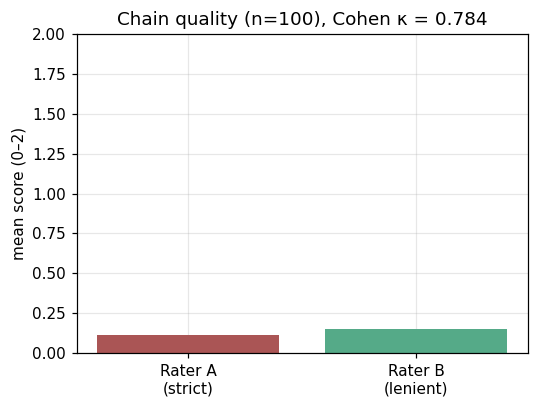

In [7]:
# Figure 5: chain-quality rubric means + inter-rater agreement (from rate_chains.py)
cq = json.loads((ROOT / "results" / "chain_quality.json").read_text())
print(f"Chain quality (n={cq['n']}): rater A mean={cq['mean_a']:.2f}, "
      f"rater B mean={cq['mean_b']:.2f}, Cohen kappa={cq['kappa']:.3f}")
fig, ax = plt.subplots(figsize=(5, 3.8))
ax.bar(["Rater A\n(strict)", "Rater B\n(lenient)"], [cq["mean_a"], cq["mean_b"]],
       color=["#a55", "#5a8"])
ax.set_ylim(0, 2); ax.set_ylabel("mean score (0–2)")
ax.set_title(f"Chain quality (n={cq['n']}), Cohen κ = {cq['kappa']:.3f}")
plt.tight_layout(); plt.show()

### 4.5 Significance

For the headline comparison — best CoT (structured) versus best fine-tune (answers) on the base model — McNemar's exact test on paired per-example correctness is computed live below. The gap is real, not seed noise: fine-tuning beats prompting on the base model. It does not change the headline, because both still lose to the plain baseline.

In [8]:
# McNemar: best CoT vs best fine-tune on the base model, seed 13.
# Derive "best" by mean EM (same rule as report_fill.py) instead of hardcoding.
def _base_em(cond):
    m, _ = _ms(r["metrics"]["exact_match"] for r in _pick(cond, "base"))
    return -1.0 if m is None else m
cot_best = max(["cot_plain", "cot_structured"], key=_base_em)
ft_best = max(["finetune_answers", "finetune_traces"], key=_base_em)
def _seed13(cond):
    return next(r for r in RESULTS if r["condition"] == cond
                and r["model"].split("/")[-1] == "flan-t5-base"
                and r["task"] == "wtq" and r["seed"] == 13)
mc = analysis.mcnemar_between(_seed13(cot_best), _seed13(ft_best))
print(f"McNemar ({cot_best} vs {ft_best}, base, seed 13): "
      f"b={mc['b']}  c={mc['c']}  discordant={mc['n_discordant']}  p={mc['pvalue']:.2e}")

McNemar (cot_structured vs finetune_answers, base, seed 13): b=5  c=65  discordant=70  p=2.22e-14


### 4.6 Compute

Inference cost (seconds per example) tracks prompt length as expected: baseline inference is cheapest, CoT (six prepended exemplars) is several times slower, and fine-tuned base inference is fastest because it emits short outputs. Every condition completed well under the two-hour-per-condition budget on a free T4 (Figure 6).

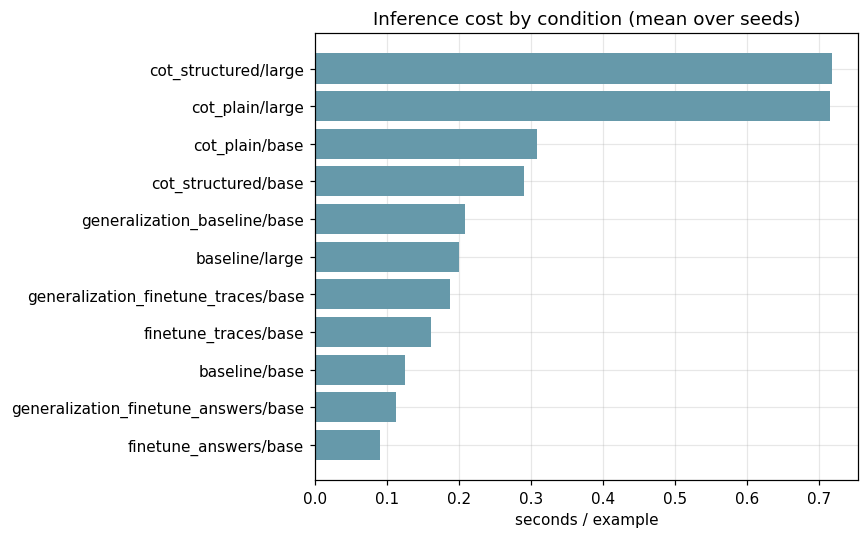

In [9]:
# Figure 6: inference cost (seconds/example) by condition
comp = {}
for r in RESULTS:
    key = f"{r['condition']}/{r['model'].split('/')[-1].split('-')[-1]}"
    comp.setdefault(key, []).append(r["compute"]["seconds_per_example"])
items = sorted(((k, st.fmean(v)) for k, v in comp.items()), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([k for k, _ in items], [v for _, v in items], color="#69a")
ax.set_xlabel("seconds / example"); ax.set_title("Inference cost by condition (mean over seeds)")
plt.tight_layout(); plt.show()

## 5. Discussion and Analysis

**Why CoT hurts.** The damage is a format effect, not a thinking effect. Under CoT, FLAN-T5 writes the reasoning out and frequently never emits the bare cell that exact match requires — e.g., it answers "The total number of senators … is 130." when the gold is "36". Token-F1, which gives partial credit, falls less steeply than EM (e.g., structured-large F1 0.197 vs. EM 0.147), confirming that some answer content survives but the surface form does not match. This is consistent with Wei et al.'s warning that models at this scale benefit little from CoT; we add that for strict-match table QA, the format mismatch turns "little benefit" into active harm.

**Why fine-tuning does not transfer.** Fine-tuning on WTQ optimizes the model to emit short factoid answers. That objective is directly at odds with TabFact, which needs a true/false token. The fine-tuned models therefore produce WTQ-style outputs on TabFact (numbers, table spans) that the verbalizer cannot map, collapsing coverage to 0.5%. The reasoning-traces variant does not rescue this: it neither improved WTQ EM nor TabFact transfer, indicating the rule-generated chains taught surface verbosity rather than transferable operations. The transfer result is thus best read as evidence of *format lock-in*, the fine-tuning analogue of the prompting format effect.

**What a practitioner should take away.** At 250M–780M on a free GPU, the highest-leverage choice is the largest model one can prompt plainly, plus attention to output format — not few-shot CoT and not a quick fine-tune, both of which cost accuracy here. The most reliable signal in our study is the simplest baseline.

**Limitations and threats to validity.** (1) Eval is a seeded 1,000-example slice (500 for CoT), not the full test set, to stay under budget; the small standard deviations across two seeds suggest the slice is stable, but it is still a sample. (2) Only the base model was fine-tuned; the large model's fine-tuning behavior is unknown because it OOMs on a T4. (3) The error-type labels are heuristic (question-cue based), so the breakdown is approximate. (4) The trace generator covers only unambiguous derivations (46.8% of rows), so CC leans on plain answers for the remainder, which may dilute any trace effect. (5) The TabFact accuracies are format-compliance numbers under distribution shift and should not be read as reasoning scores; we report the decomposition precisely so they are not misused.

## 6. Conclusion

We asked whether chain-of-thought prompting or supervised fine-tuning better helps a small, free-tier model read tables, and the answer at this scale is *neither*. The plain zero-shot baseline on FLAN-T5-large was the best system at 0.241 exact match; CoT more than halved exact match, light fine-tuning landed below the baseline, and the WTQ-fine-tuned models did not transfer to TabFact — their outputs collapsed to a non-true/false format, leaving accuracy below the 0.551 majority floor. The mechanisms are two faces of the same problem: small models manage table content but not the required output format, and both CoT and fine-tuning worsen that mismatch. For anyone on a small compute budget, the practical recommendation is to prompt the largest available model plainly and invest in output formatting, rather than in few-shot reasoning or a quick fine-tune. As a negative result, fully reproducible and with every number traced to a file, this is a useful data point for the small-model table-reasoning regime that the literature has largely left unexamined.

## Contribution Statement

- **Adisesh Venkatesh** built the shared core library and the baseline condition, wrote the dataset and experimental-setup components, and co-designed and applied the chain-quality rating rubrics.
- **Amar Thota** implemented and ran both chain-of-thought conditions (plain and structured) on both models, led the hand-written CoT exemplars, and assembled the slide deck.
- **Nikhil Karthikeyan** built the seq2seq training harness, ran the answers-only fine-tuning across both seeds, and co-designed and applied the chain-quality rating rubrics.
- **Anant Madhok** built the rule-based reasoning-trace generator and ran the reasoning-traces fine-tuning across both seeds.
- **Sanjay Manivasagam** led and coordinated the project, ran the TabFact generalization test, and produced the error analysis, the statistical tests (McNemar, Cohen's κ, mean/std), the results tables and plots, and the merged report.

## References

[1] Chen, W., Wang, H., Chen, J., Zhang, Y., Wang, H., Li, S., Zhou, X., & Wang, W. Y. (2020). *TabFact: A Large-scale Dataset for Table-based Fact Verification.* ICLR 2020.

[2] Herzig, J., Nowak, P. K., Müller, T., Piccinno, F., & Eisenschlos, J. M. (2020). *TAPAS: Weakly Supervised Table Parsing via Pre-training.* ACL 2020.

[3] Pasupat, P., & Liang, P. (2015). *Compositional Semantic Parsing on Semi-Structured Tables.* ACL 2015.

[4] Wang, X., Wei, J., Schuurmans, D., Le, Q., Chi, E., Narang, S., Chowdhery, A., & Zhou, D. (2023). *Self-Consistency Improves Chain of Thought Reasoning in Language Models.* ICLR 2023.

[5] Wei, J., Wang, X., Schuurmans, D., Bosma, M., Ichter, B., Xia, F., Chi, E., Le, Q., & Zhou, D. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models.* NeurIPS 2022.

[6] Xie, T., Wu, C. H., Shi, P., Zhong, R., Scholak, T., Yasunaga, M., et al. (2022). *UnifiedSKG: Unifying and Multi-Tasking Structured Knowledge Grounding with Text-to-Text Language Models.* EMNLP 2022.

[7] Yao, S., Yu, D., Zhao, J., Shafran, I., Griffiths, T. L., Cao, Y., & Narasimhan, K. (2023). *Tree of Thoughts: Deliberate Problem Solving with Large Language Models.* NeurIPS 2023.